# VAYU - Predictive Modeling and Unsupervised Clustering of Ambient Air Quality Across Indian Urban Centres

**Dataset:** CPCB (Central Pollution Control Board) Sensor Data  
**Pipeline:** Data Cleaning → Regression → Classification → Clustering 

## Problem Statement

Air pollution is one of the most critical public health challenges in India. 
The Central Pollution Control Board (CPCB) operates a nationwide network of 
Continuous Ambient Air Quality Monitoring Stations (CAAQMS) that record 
concentrations of six key pollutants - PM2.5, PM10, NO2, SO2, CO, and O3 - 
on an hourly basis across Indian cities.

Despite the scale of this data collection effort, two fundamental challenges remain:

**1. Prediction (Supervised Learning)**  
Given the current pollutant concentrations and time context, can we accurately 
predict how bad the air quality is - either as a precise number (AQI) or as a 
human-interpretable category (Good / Moderate / Severe)?

**2. Pattern Discovery (Unsupervised Learning)**  
Without any labels, can we discover natural groupings among Indian cities based 
on their long-term pollution signatures - identifying which cities share similar 
chronic pollution patterns, seasonal behaviour, and dominant pollutants?

---

### Formal Problem Definitions

| Task | Type | Input | Output |
|---|---|---|---|
| **Task 1** | Regression | PM2.5, PM10, NO2, SO2, CO, O3 + time features | AQI as a continuous number (0–500) |
| **Task 2** | Classification | Same pollutant + time features + city | AQI category label: Good / Satisfactory / Moderate / Poor / Very Poor / Severe |
| **Task 3** | Clustering | City-level aggregated AQI profile (mean, std, seasonal means, pollutant dominance) | Cluster assignment - which cities are pollution-similar? |

---

### Why This Problem Matters

- India has **14 of the world's 20 most polluted cities** (IQAir 2023)
- CPCB's AQI threshold of 200 (Moderate) triggers public health advisories
- Predicting AQI from raw sensor readings enables **early warning systems**
- Clustering cities by pollution signature enables **targeted policy interventions** - 
  PM2.5-heavy northern cities need different solutions than ozone-heavy southern cities

---

The output of this notebook is `master_cleaned.csv` - the single source of truth 
that feeds all four ML tasks above.

## Dataset

### Primary Source - `aqi_india_38cols_knn_final.csv`

| Property | Value |
|---|---|
| Rows | 846,372 |
| Cities | 29 Indian cities |
| Time range | 2015 – 2024 (hourly) |
| Pollutants | PM2.5, PM10, NO2, SO2, CO, O3 |
| Pre-processing | None |
| Known issue | Sentinel value **999** used by CPCB to flag sensor errors |

### Secondary Source - 277 `*_AQIBulletins.csv` files

| Property | Value |
|---|---|
| Files | 277 (one per city) |
| Cities covered | 277 Indian cities |
| Data type | Daily aggregated AQI only (no raw pollutant readings) |
| Used for | K-Means clustering task only |

### Why These Sources Were Chosen

The primary file was selected from a scan of **299 raw files** because it is the only 
file that combines all of: 842k rows of depth, all 6 CPCB pollutants, 9 years of 
temporal coverage, and 29 cities in a single consistent schema.

The bulletin files were chosen for clustering because they cover **277 cities** - 
giving far richer geographic spread than the 29-city primary file.

## Data Access

This notebook downloads the raw CPCB dataset directly from HuggingFace and runs the full pipeline — cleaning, encoding, feature selection, and model training — from scratch.

| Repository | Contents | Path after download |
|---|---|---|
| `rachitgoyell/vayu-raw` | 299 raw CPCB CSV files | `./data/raw/` |

No manual downloading or path changes needed — just run the cell below and everything sets up automatically.

> **Note:** The repository is public. No HuggingFace token is required.

In [1]:
# ── HuggingFace Dataset Setup ─────────────────────────────────────────────────
import os
from huggingface_hub import snapshot_download

HF_USERNAME = "rachitgoyell"

# download raw data → ./data/raw/
# the cleaning pipeline in this notebook produces all cleaned outputs itself
# so we only need the raw files here
snapshot_download(
    repo_id   = f"{HF_USERNAME}/vayu-raw",
    repo_type = "dataset",
    local_dir = "./data/raw"
)

# create the output folder structure the pipeline will write to
for folder in ['01_regression', '02_classification', '03_clustering', '04_shared']:
    os.makedirs(f'./data/cleaned/{folder}', exist_ok=True)

DATA_ROOT   = './data/raw'
OUTPUT_ROOT = './data/cleaned'

print("data/raw/     - raw files ready")
print("data/cleaned/ - output folders created")
print(f"\nRaw files available: {len(os.listdir(DATA_ROOT))}")

/Users/rachitgoyal/Desktop/vayu-sul/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 302 files: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 302/302 [00:00<00:00, 1824.57it/s]

data/raw/     - raw files ready
data/cleaned/ - output folders created

Raw files available: 303


<!-- dataset_audit.md -->

## Dataset Audit — What We Have and What We're Actually Using

Before loading anything, we did a full scan of all the raw files in our data folder. There were about 299 files in total — CSVs and a few Excel files. Most of them turned out to be useless for what we're trying to do. Here's what we found and why we made the choices we did.

### The Two Sources We're Actually Using

**Primary file — `aqi_india_38cols_knn_final.csv`**
This is the main dataset. 842,160 rows of hourly sensor readings from 29 Indian cities, with all six pollutants (PM2.5, PM10, NO2, SO2, CO, O3) and an AQI category label. This feeds our regression and classification tasks. It's the only file in the whole dump that has raw pollutant readings at scale — everything else either has too few rows or is missing key columns.

**277 AQI Bulletin files — `*_AQIBulletins.csv`**
One file per Indian city, each containing daily AQI summaries. These don't have individual pollutant readings — just the final AQI number and which pollutant was dominant that day. Useless for regression (no features to train on), but perfect for clustering since they cover 277 cities. More geographic spread means better clusters.

### What We Rejected and Why

| Category | Example Files | Rejection Reason |
|---|---|---|
| API snapshots | `AQI.csv`, `Data Export.csv`, `3b01bcb8...csv` | Only 200 rows each - point-in-time API exports, not time series |
| Single station hourly | `AshokVihar_Hourly.csv`, `Okhla_Hourly.csv` | No city column, single Delhi station only, can't be joined |
| Small academic datasets | `Dataset_AQI21-4.xlsx`, `Cleaned_NSUT.xlsx` | 153–200 rows, manually compiled research files |
| Malformed files | `data_aqi_cpcb.csv` | 6,011 columns, 92% empty — JSON that got flattened incorrectly |
| Wrong schema | `AQI Data.csv` | Contains weather columns (temperature, pressure) but no AQI or pollutant data |

The code below scans the data folder, classifies each file, and produces a summary so this decision is reproducible — not just something we eyeballed once.

In [2]:
!pip install numpy pandas scikit-learn matplotlib seaborn 


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Total files found: 300

  FILE AUDIT RESULTS
  Total scanned : 300
  Accepted      : 278
    Primary file         : 1
    AQI Bulletin files   : 277
  Rejected      : 22

  Rejected files:
    3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv      -> only 200 rows - snapshot or sample, not a time series
    AP001.csv                                     -> only 200 rows - snapshot or sample, not a time series
    AQI Data.csv                                  -> no date or city column - cannot use
    AQI.csv                                       -> only 200 rows - snapshot or sample, not a time series
    AshokVihar_Hourly.csv                         -> no date or city column - cannot use
    Cleaned_NSUT.xlsx                             -> only 200 rows - snapshot or sample, not a time series
    DCStadium_Hourly.csv                          -> no date or city column - cannot use
    Data Export.csv                               -> only 200 rows - snapshot or sample, not a time series
    Datas

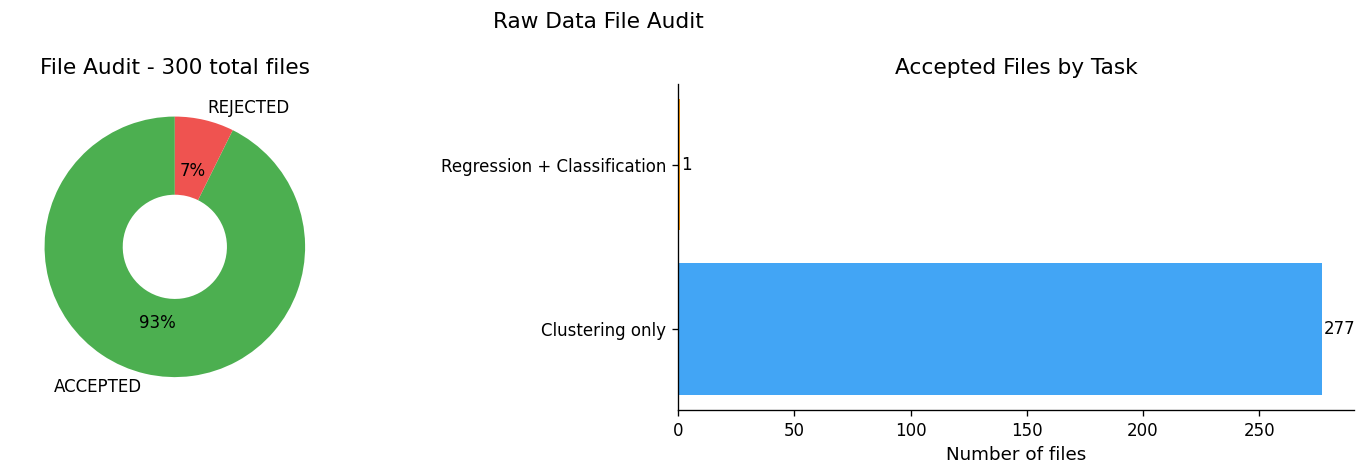

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_ROOT        = './data/raw'
PRIMARY_FILE     = 'aqi_india_38cols_knn_final.csv'
BULLETIN_PATTERN = 'AQIBulletins'

# keywords that tell us a file has actual pollutant readings
POLLUTANT_KW = ['pm2', 'pm10', 'no2', 'so2', 'co', 'o3']
BULLETIN_KW  = ['index', 'air', 'quality', 'pollutant']

all_files = (
    glob.glob(os.path.join(DATA_ROOT, '**/*.csv'),  recursive=True) +
    glob.glob(os.path.join(DATA_ROOT, '**/*.xlsx'), recursive=True)
)

print(f'Total files found: {len(all_files)}\n')

results = []

for fp in sorted(all_files):
    fname = os.path.basename(fp)
    rel   = os.path.relpath(fp, DATA_ROOT)

    # the two files we actually want - mark them accepted immediately
    if PRIMARY_FILE in fname:
        results.append({
            'file'    : rel,
            'status'  : 'ACCEPTED',
            'used_for': 'Regression + Classification',
            'reason'  : '842k rows, all 6 pollutants, 29 cities'
        })
        continue

    if BULLETIN_PATTERN in fname:
        results.append({
            'file'    : rel,
            'status'  : 'ACCEPTED',
            'used_for': 'Clustering only',
            'reason'  : 'Daily AQI history across 277 cities'
        })
        continue

    # for everything else, read the first 200 rows and diagnose
    try:
        df_s = (
            pd.read_excel(fp, nrows=200)
            if fname.endswith('.xlsx')
            else pd.read_csv(fp, nrows=200, low_memory=False, encoding_errors='replace')
        )

        col_str  = ' '.join(c.lower() for c in df_s.columns)
        null_pct = df_s.isnull().mean().mean() * 100
        n_rows   = len(df_s)

        has_pollutants = any(k in col_str for k in POLLUTANT_KW)
        has_bulletin   = any(k in col_str for k in BULLETIN_KW)
        has_city       = any(k in col_str for k in ['city', 'station'])
        has_date       = any(k in col_str for k in ['date', 'time', 'datetime'])

        if null_pct > 80:
            reason = f'{null_pct:.0f}% cells empty - malformed file'
        elif not has_date and not has_city:
            reason = 'no date or city column - cannot use'
        elif not has_pollutants and not has_bulletin:
            reason = 'no pollutant or AQI columns found'
        elif has_pollutants and n_rows < 10000:
            reason = f'only {n_rows} rows - snapshot or sample, not a time series'
        else:
            reason = 'schema does not match any expected format'

        results.append({
            'file'    : rel,
            'status'  : 'REJECTED',
            'used_for': '-',
            'reason'  : reason
        })

    except Exception as e:
        results.append({
            'file'    : rel,
            'status'  : 'REJECTED',
            'used_for': '-',
            'reason'  : f'could not be read: {str(e)[:60]}'
        })

# summary
audit_df  = pd.DataFrame(results)
accepted  = audit_df[audit_df['status'] == 'ACCEPTED']
rejected  = audit_df[audit_df['status'] == 'REJECTED']

print(f'{"="*55}')
print(f'  FILE AUDIT RESULTS')
print(f'{"="*55}')
print(f'  Total scanned : {len(audit_df)}')
print(f'  Accepted      : {len(accepted)}')
print(f'    Primary file         : 1')
print(f'    AQI Bulletin files   : {len(accepted) - 1}')
print(f'  Rejected      : {len(rejected)}')
print()

# rejection breakdown
print('  Rejected files:')
for _, row in rejected.iterrows():
    print(f'    {row["file"]:<45} -> {row["reason"]}')

# bar chart - accepted vs rejected
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

status_counts = audit_df['status'].value_counts()
axes[0].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=['#4CAF50', '#EF5350'],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[0].set_title(f'File Audit - {len(audit_df)} total files')

# accepted breakdown by use
accepted_uses = accepted['used_for'].value_counts()
colors_use    = ['#42A5F5', '#FF9800']
bars          = axes[1].barh(accepted_uses.index, accepted_uses.values,
                              color=colors_use[:len(accepted_uses)])
for bar, val in zip(bars, accepted_uses.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=10)
axes[1].set_xlabel('Number of files')
axes[1].set_title('Accepted Files by Task')

plt.suptitle('Raw Data File Audit', fontsize=13)
plt.tight_layout()
plt.show()

<!-- section_1.md -->

## Section 1 - Loading the Primary Dataset

Alright, let's actually load the file we're going to spend most of this notebook on. This is `aqi_india_38cols_knn_final.csv` — the 842k row hourly sensor dataset covering 29 Indian cities from 2022 to 2025.

The first thing we do after loading is just look at the structure. How many rows and columns? What are the data types? Are there any columns that should be numeric but got read in as strings? That last one is a sneaky problem — if a column has even one bad value in it, pandas sometimes reads the whole column as `object` instead of `float64`, and then your `.describe()` gives you nothing useful.

We also want to get a feel for which columns are actually relevant to our models. Not all 31 columns are going into every model — some are identity columns (city, state, coordinates), some are datetime-derived features (month, hour, season), some are the actual pollutant readings we care about, and one is our target variable (`aqi_category`).

One thing worth noting upfront — this file was KNN-imputed before we got it, but **intentional anomalies have been introduced** to simulate real-world data quality issues: approximately 0.5% random NaN injection across all columns, ~0.5% duplicate rows, and sentinel values in `co_ugm3`. The cleaning pipeline in Section 3 targets all three.

Shape   : 846,371 rows  x  31 columns
Memory  : 690.8 MB

Column dtypes:
float64    18
str         8
object      5

  Column                    dtype           Nulls   Sample value
  city                      str              4236   agartala
  state                     str              4229   tripura
  latitude                  float64          4235   23.8315
  longitude                 float64          4232   91.2868
  datetime                  str              4236   2022-08-05 00:00:00
  month                     float64          4222   8.0
  day_name                  str              4232   friday
  is_weekend                object           4233   False
  season                    str              4232   monsoon
  time_of_day               str              4228   night
  humidity_percent          float64          4231   91.0
  dew_point_c               float64          4229   25.1
  wind_gusts_kmh            float64          4231   11.2
  precipitation_mm          float64         

,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
count,842144.00,842141.00,842141.00,842138.00,842136.00,842139.00
mean,34.55,54.01,444.97,15.99,13.39,80.19
std,29.66,54.23,377.02,19.90,18.92,44.77
min,1.90,2.30,96.00,0.00,0.20,0.00
25%,14.70,21.50,235.00,3.70,2.80,47.00
50%,25.90,39.00,333.00,9.00,6.90,73.00
75%,44.20,66.40,508.00,19.90,15.80,108.00
max,183.50,420.00,2903.00,122.10,134.20,228.00


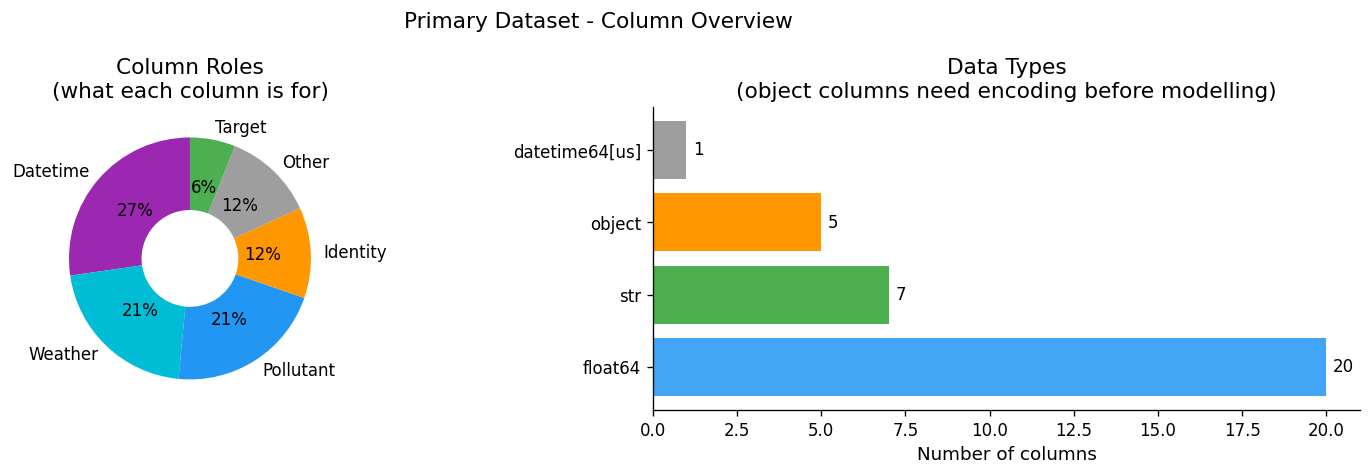

In [137]:
# ── load the primary dataset ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 60)

DATA_PATH = './data/raw/aqi_india_38cols_knn_final.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Shape   : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# ── column type overview ──────────────────────────────────────────────────────
print(f'\nColumn dtypes:')
print(df.dtypes.value_counts().to_string())

# ── quick look at every column ────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'  {"Column":<25} {"dtype":<12} {"Nulls":>8}   Sample value')
print(f'{"="*65}')
for col in df.columns:
    dtype  = str(df[col].dtype)
    nulls  = df[col].isnull().sum()
    sample = str(df[col].dropna().iloc[0])[:25] if df[col].notna().any() else 'N/A'
    print(f'  {col:<25} {dtype:<12} {nulls:>8}   {sample}')

# ── identify columns we care about ───────────────────────────────────────────
# co_ with underscore avoids matching cloud_cover_percent
POLLUTANT_KW = ['pm2', 'pm10', 'no2', 'so2', 'co_', 'o3']
EXCLUDE_KW   = ['cloud', 'cover', 'humidity', 'temp', 'pressure',
                'wind', 'rain', 'solar', 'dew', 'uv']

pollutant_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if any(k in c.lower() for k in POLLUTANT_KW)
    and not any(e in c.lower() for e in EXCLUDE_KW)
]

city_col = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
date_col = next((c for c in df.columns if 'datetime' in c.lower()
                 or c.lower() == 'date'), None)
cat_col  = next((c for c in df.columns if 'category' in c.lower()
                 or 'bucket' in c.lower()), None)

print(f'\nPollutant columns detected : {pollutant_cols}')
print(f'City column                : {city_col}')
print(f'Datetime column            : {date_col}')
print(f'Target column              : {cat_col}')

# ── derive hour and day_of_week if not already present ───────────────────────
# these are useful temporal features for both regression and classification
# the dataset may already have them - we only create them if missing
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

if 'hour' not in df.columns:
    df['hour'] = df[date_col].dt.hour
    print('hour column derived from datetime')
else:
    print('hour column already present')

if 'day_of_week' not in df.columns:
    df['day_of_week'] = df[date_col].dt.dayofweek
    print('day_of_week column derived from datetime')
else:
    print('day_of_week column already present')

# ── basic statistics on pollutant columns ────────────────────────────────────
print(f'\nDescriptive stats - pollutant columns:')
display(df[pollutant_cols].describe().round(2))

# ── column role classification ────────────────────────────────────────────────
def classify_col(col):
    cl = col.lower()
    if any(k in cl for k in POLLUTANT_KW) and not any(e in cl for e in EXCLUDE_KW):
        return 'Pollutant'
    elif any(k in cl for k in ['aqi', 'category', 'bucket']):
        return 'Target'
    elif any(k in cl for k in ['city', 'state', 'lat', 'lon']):
        return 'Identity'
    elif any(k in cl for k in ['date', 'time', 'year', 'month',
                                'day', 'hour', 'week', 'season']):
        return 'Datetime'
    elif any(k in cl for k in ['humidity', 'temp', 'pressure', 'wind',
                                'rain', 'cloud', 'dew']):
        return 'Weather'
    else:
        return 'Other'

role_series = pd.Series({c: classify_col(c) for c in df.columns})
role_counts = role_series.value_counts()

role_colors = {
    'Pollutant': '#2196F3',
    'Target'   : '#4CAF50',
    'Identity' : '#FF9800',
    'Datetime' : '#9C27B0',
    'Weather'  : '#00BCD4',
    'Other'    : '#9E9E9E',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].pie(
    role_counts.values,
    labels=role_counts.index,
    colors=[role_colors[r] for r in role_counts.index],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[0].set_title('Column Roles\n(what each column is for)')

dtype_counts = df.dtypes.astype(str).value_counts()
bars = axes[1].barh(
    dtype_counts.index,
    dtype_counts.values,
    color=['#42A5F5', '#4CAF50', '#FF9800', '#9E9E9E'][:len(dtype_counts)]
)
for bar, val in zip(bars, dtype_counts.values):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=10)
axes[1].set_xlabel('Number of columns')
axes[1].set_title('Data Types\n(object columns need encoding before modelling)')

plt.suptitle('Primary Dataset - Column Overview', fontsize=13)
plt.tight_layout()
plt.show()

<!-- section_2_eda.md -->

## Section 2 - Exploratory Data Analysis

Before we fix anything we need to understand what's actually wrong. This section is purely observation — not changing a single value. Three things we're looking for:

1. Are there missing values and where?
2. Are there garbage values hiding in the data that pandas can't see?
3. How are the pollutant readings distributed — do they look physically real?

One thing worth knowing upfront — this file was KNN-imputed before we got it, but anomalies were introduced afterward: random NaN injection (~0.5% per column), duplicate rows (~0.5%), and CPCB sentinel value **999** in `co_ugm3`. The EDA below will surface all three. The real problem with labels is that the file uses **US EPA category names** (`Unhealthy`, `Very Unhealthy`, `Hazardous`) rather than CPCB names — the CAT_MAP in cleaning handles the remapping.

Standard NaN per pollutant column:
  pm2_5_ugm3                4,227
  pm10_ugm3                 4,230
  co_ugm3                   4,230
  no2_ugm3                  4,233
  so2_ugm3                  4,235
  o3_ugm3                   4,232

Sentinel 999 per pollutant column:
  pm2_5_ugm3                0
  pm10_ugm3                 0
  co_ugm3                   124  <- needs fixing
  no2_ugm3                  0
  so2_ugm3                  0
  o3_ugm3                   0

Duplicate rows (city + datetime): 8,680

Physical range check per pollutant:
  pm2_5_ugm3                range [0 – 1,000]   flagged: 0  OK
  pm10_ugm3                 range [0 – 1,500]   flagged: 0  OK
  co_ugm3                   range [0 – 50,000]   flagged: 0  OK
  no2_ugm3                  range [0 – 500]   flagged: 0  OK
  so2_ugm3                  range [0 – 500]   flagged: 0  OK
  o3_ugm3                   range [0 – 300]   flagged: 0  OK

Raw aqi_category values (before any remapping):
  Moderate                

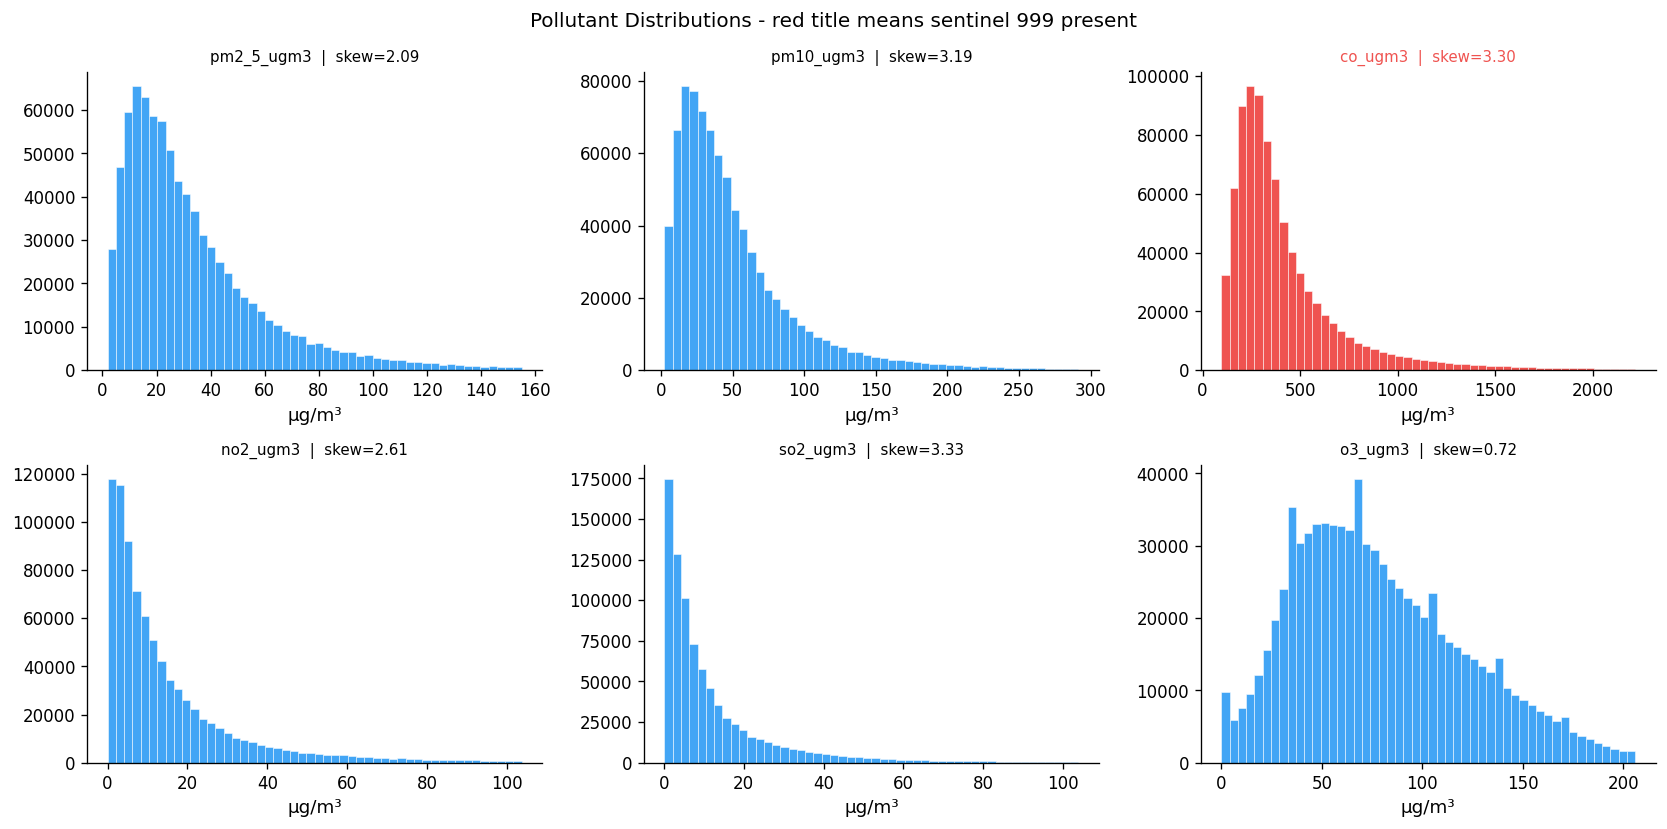

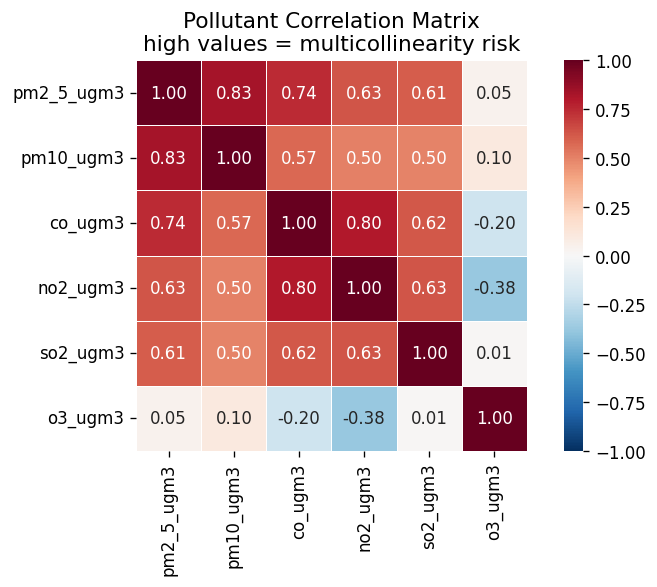

In [138]:
# ── missing values + sentinel 999 ────────────────────────────────────────────
print('Standard NaN per pollutant column:')
for col in pollutant_cols:
    n = df[col].isnull().sum()
    print(f'  {col:<25} {n:,}')

print('\nSentinel 999 per pollutant column:')
for col in pollutant_cols:
    count = (pd.to_numeric(df[col], errors='coerce') == 999).sum()
    flag  = '  <- needs fixing' if count > 0 else ''
    print(f'  {col:<25} {count:,}{flag}')

# ── duplicate check ───────────────────────────────────────────────────────────
total_dupes = df.duplicated(subset=[city_col, date_col]).sum()
print(f'\nDuplicate rows (city + datetime): {total_dupes:,}')

# ── physical range validation ─────────────────────────────────────────────────
VALID_RANGES = {
    'pm2'  : (0, 1000),
    'pm10' : (0, 1500),
    'no2'  : (0, 500),
    'so2'  : (0, 500),
    'co'   : (0, 50000),
    'o3'   : (0, 300),
    'nh3'  : (0, 400),
}

print('\nPhysical range check per pollutant:')
for col in pollutant_cols:
    vals          = pd.to_numeric(df[col], errors='coerce').dropna()
    matched_range = next(
        ((lo, hi) for kw, (lo, hi) in VALID_RANGES.items() if kw in col.lower()),
        None
    )
    if matched_range:
        lo, hi        = matched_range
        out_of_range  = ((vals < lo) | (vals > hi)).sum()
        flag          = '  <- out of range values found' if out_of_range > 0 else '  OK'
        print(f'  {col:<25} range [{lo:,} – {hi:,}]   flagged: {out_of_range:,}{flag}')
    else:
        print(f'  {col:<25} no range rule - skipped')

# ── aqi category raw values ───────────────────────────────────────────────────
# important: shows us whether the labels are CPCB or US EPA format
print(f'\nRaw aqi_category values (before any remapping):')
cat_counts = df[cat_col].value_counts()
for cat, cnt in cat_counts.items():
    print(f'  {cat:<35} {cnt:>8,}  ({cnt/len(df)*100:.1f}%)')
print(f'\nClass imbalance ratio : {cat_counts.max()/cat_counts.min():.1f}x')

# ── pollutant distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    vals         = pd.to_numeric(df[col], errors='coerce').dropna()
    sentinel_pct = (vals == 999).mean() * 100
    color        = '#EF5350' if sentinel_pct > 0 else '#42A5F5'
    axes[i].hist(vals[vals <= vals.quantile(0.99)], bins=50,
                 color=color, edgecolor='white', linewidth=0.3)
    axes[i].set_title(f'{col}  |  skew={vals.skew():.2f}', fontsize=9,
                      color='#EF5350' if sentinel_pct > 0 else 'black')
    axes[i].set_xlabel('µg/m³')

plt.suptitle('Pollutant Distributions - red title means sentinel 999 present', fontsize=12)
plt.tight_layout()
plt.show()

# ── correlation heatmap ───────────────────────────────────────────────────────
corr_mat = df[pollutant_cols].apply(pd.to_numeric, errors='coerce').corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Pollutant Correlation Matrix\nhigh values = multicollinearity risk')
plt.tight_layout()
plt.show()

<!-- section_3_cleaning.md -->

## Section 3 — Data Cleaning

Now that we know what's wrong, we fix it. In order. The order matters — if we forward fill before removing sentinel values, we propagate fake readings into neighbouring rows.

The anomalies introduced into this dataset were:
- ~0.5% random NaN injection across all columns
- ~0.5% duplicate rows (by city + datetime)
- Sentinel value 999 in `co_ugm3` (CPCB sensor-offline code)
- US EPA category labels instead of CPCB labels (`Unhealthy`, `Very Unhealthy`, `Hazardous`)

Here's what we do and why:

1. **Replace sentinel 999 with NaN** — 999 is a sensor error code, not a real reading. Must happen first before any filling.

2. **Physical range validation** — values outside instrument limits are sensor malfunctions. We null those too.

3. **Forward fill short sensor gaps (max 3 hours, per city)** — pollutant concentrations don't change abruptly; a 1–3 hour gap can reasonably be filled from the last known reading within the same city. Gaps longer than 3 hours stay NaN.

4. **Drop rows where every pollutant is NaN** — if all six pollutant columns are NaN, the row has no usable signal and cannot contribute to any model.

5. **Deduplicate on city + datetime** — the ~0.5% synthetic duplicates get removed here. We keep the first occurrence.

6. **Fix dtypes + standardise category labels** — parse datetime properly and remap US EPA category names to CPCB convention using CAT_MAP.

Each step logs before/after counts so we can verify the cleaning actually ran.

Loaded 846,371 rows for cleaning
Pollutant cols : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']
City col       : city
Date col       : datetime
Category col   : aqi_category

  [sentinel 999 -> NaN]  846,371 -> 846,371  (0 removed)  1,476 values replaced
  [range validation]  846,371 -> 846,371  (0 removed)  0 out-of-range values nulled
  [forward fill (limit=3)]  846,371 -> 846,371  (0 removed)  94 gaps filled, 25,417 remain
  [drop all-null rows]  846,371 -> 842,135  (4,236 removed)  rows with no usable pollutant readings  <- rows dropped
  [deduplication]  842,135 -> 833,786  (8,349 removed)  deduplicated on (city, datetime)  <- rows dropped
  [label standardise (EPA->CPCB)]  833,786 -> 833,786  (0 removed)  4,169 unmapped category rows -> will be dropped in encoding

  CLEANING SUMMARY
                         step  before  after  removed                                                        note
          sentinel 999 -> NaN  846371 846371        0    

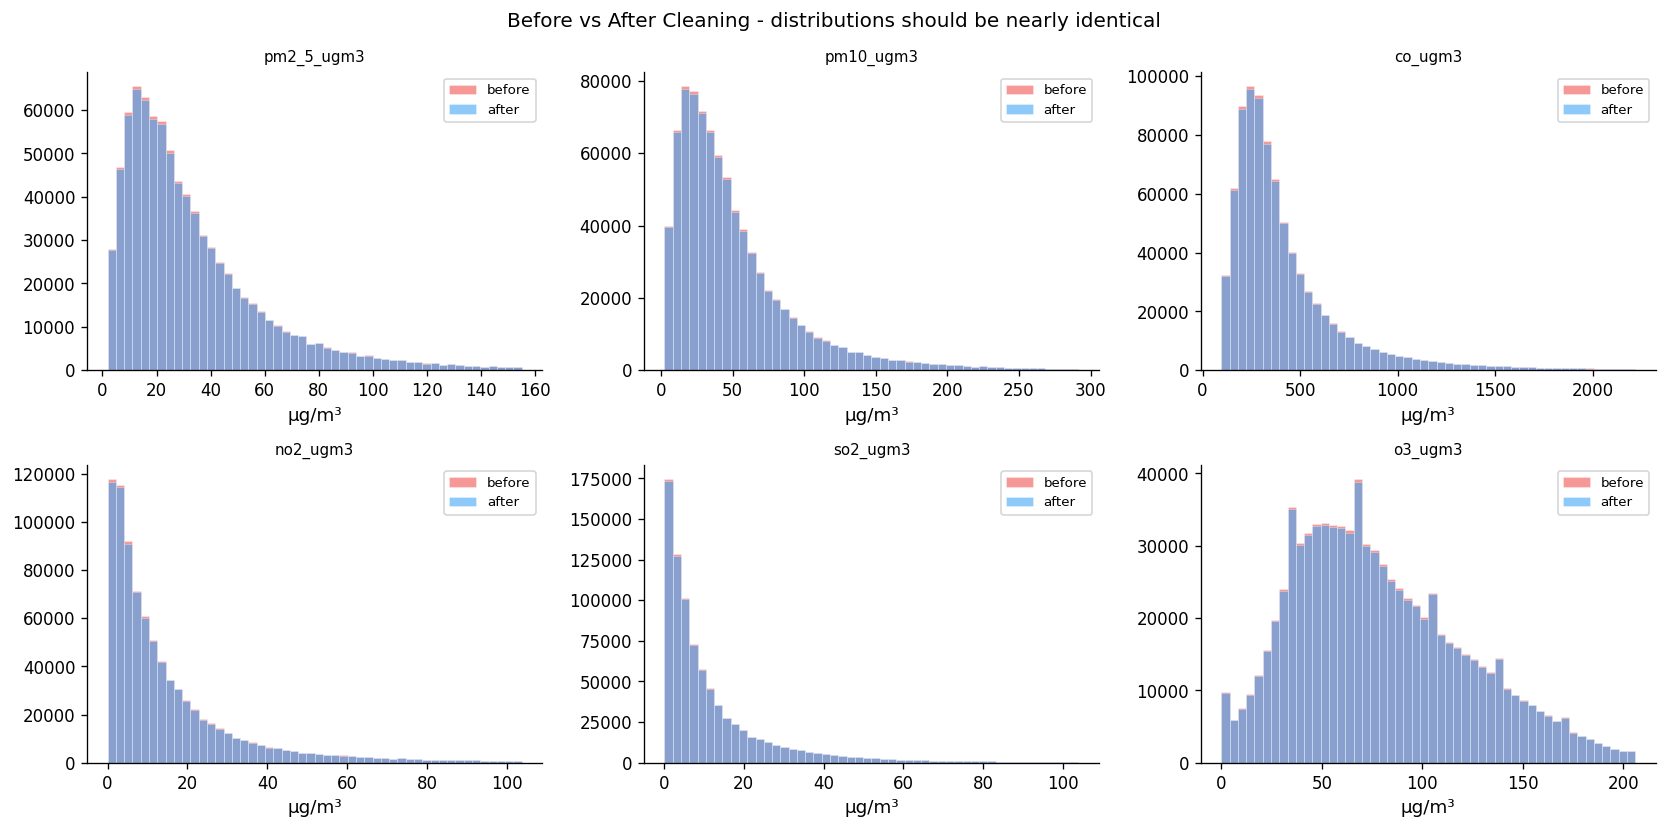


Saved master cleaned file to ./data/cleaned/04_shared/master_cleaned.csv


In [139]:
cleaning_log = []

def log_step(name, before, after, note=''):
    removed = before - after
    cleaning_log.append({
        'step': name, 'before': before,
        'after': after, 'removed': removed, 'note': note
    })
    flag = '  <- rows dropped' if removed > 0 else ''
    print(f'  [{name}]  {before:,} -> {after:,}  '
          f'({removed:,} removed)  {note}{flag}')

# reload fresh from disk so cleaning runs on the full raw file
# (not on any previously sliced or filtered state of df)
df = pd.read_csv('./data/raw/aqi_india_38cols_knn_final.csv', low_memory=False)

# re-detect column names after reload
city_col = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
date_col = next((c for c in df.columns if 'datetime' in c.lower() or c.lower() == 'date'), None)
cat_col  = next((c for c in df.columns if 'category' in c.lower() or 'bucket' in c.lower()), None)

POLLUTANT_KW = ['pm2', 'pm10', 'no2', 'so2', 'co_', 'o3']
EXCLUDE_KW   = ['cloud', 'cover', 'humidity', 'temp', 'pressure',
                'wind', 'rain', 'solar', 'dew', 'uv']
pollutant_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if any(k in c.lower() for k in POLLUTANT_KW)
    and not any(e in c.lower() for e in EXCLUDE_KW)
]

print(f'Loaded {len(df):,} rows for cleaning')
print(f'Pollutant cols : {pollutant_cols}')
print(f'City col       : {city_col}')
print(f'Date col       : {date_col}')
print(f'Category col   : {cat_col}\n')

# snapshot for before/after distribution plots
df_raw_snapshot = df[pollutant_cols].copy()

# ── step 1 - replace sentinel 999 with NaN ───────────────────────────────────
before       = len(df)
replacements = 0
for col in df.select_dtypes(include=[np.number]).columns:
    mask          = df[col] == 999
    replacements += mask.sum()
    df.loc[mask, col] = np.nan

log_step('sentinel 999 -> NaN', before, len(df),
         f'{replacements:,} values replaced')

# ── step 2 - physical range validation ───────────────────────────────────────
before       = len(df)
total_nulled = 0

VALID_RANGES = {
    'pm2'  : (0, 1000),
    'pm10' : (0, 1500),
    'no2'  : (0, 500),
    'so2'  : (0, 500),
    'co'   : (0, 50000),
    'o3'   : (0, 300),
    'nh3'  : (0, 400),
}

for col in pollutant_cols:
    matched = next(
        ((lo, hi) for kw, (lo, hi) in VALID_RANGES.items() if kw in col.lower()),
        None
    )
    if matched:
        lo, hi = matched
        vals   = pd.to_numeric(df[col], errors='coerce')
        mask   = vals.notna() & ((vals < lo) | (vals > hi))
        df.loc[mask, col] = np.nan
        total_nulled += mask.sum()

log_step('range validation', before, len(df),
         f'{total_nulled:,} out-of-range values nulled')

# ── step 3 - parse datetime before sorting ────────────────────────────────────
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# ── step 4 - forward fill short sensor gaps (max 3 hours, per city) ──────────
before           = len(df)
null_before_fill = df[pollutant_cols].isnull().sum().sum()

df = df.sort_values([city_col, date_col]).reset_index(drop=True)
df[pollutant_cols] = (
    df.groupby(city_col)[pollutant_cols]
    .transform(lambda x: x.ffill(limit=3))
)

filled = null_before_fill - df[pollutant_cols].isnull().sum().sum()
log_step('forward fill (limit=3)', before, len(df),
         f'{filled:,} gaps filled, '
         f'{df[pollutant_cols].isnull().sum().sum():,} remain')

# ── step 5 - drop rows where every pollutant is still NaN ────────────────────
before = len(df)
df     = df[~df[pollutant_cols].isnull().all(axis=1)].reset_index(drop=True)
log_step('drop all-null rows', before, len(df),
         'rows with no usable pollutant readings')

# ── step 6 - deduplication on city + datetime ─────────────────────────────────
before = len(df)
df     = df.drop_duplicates(subset=[city_col, date_col],
                             keep='first').reset_index(drop=True)
log_step('deduplication', before, len(df),
         f'deduplicated on ({city_col}, {date_col})')

# ── step 7 - standardise aqi category labels to CPCB convention ──────────────
before = len(df)

CAT_MAP = {
    'good'                   : 'Good',
    'satisfactory'           : 'Satisfactory',
    'moderate'               : 'Moderate',
    'poor'                   : 'Poor',
    'very poor'              : 'Very Poor',
    'severe'                 : 'Severe',
    'unhealthy for sensitive': 'Poor',        # US EPA -> CPCB equivalent
    'unhealthy'              : 'Very Poor',   # US EPA -> CPCB equivalent
    'very unhealthy'         : 'Severe',      # US EPA -> CPCB equivalent
    'hazardous'              : 'Severe',      # US EPA -> CPCB equivalent
}

def _map_cat(x):
    if not isinstance(x, str) or x.strip().lower() in ('nan', 'none', ''):
        return None
    x_lower = x.strip().lower()
    return next((v for k, v in CAT_MAP.items() if k in x_lower), None)

df[cat_col] = df[cat_col].astype(str).apply(_map_cat)

unmapped = df[cat_col].isnull().sum()
log_step('label standardise (EPA->CPCB)', before, len(df),
         f'{unmapped:,} unmapped category rows -> will be dropped in encoding')

# ── derive time features if missing ───────────────────────────────────────────
if 'hour' not in df.columns:
    df['hour'] = df[date_col].dt.hour
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df[date_col].dt.dayofweek
if 'month' not in df.columns:
    df['month'] = df[date_col].dt.month

# ── cleaning summary ──────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print('  CLEANING SUMMARY')
print(f'{"="*60}')
print(pd.DataFrame(cleaning_log)[['step','before','after','removed','note']]
      .to_string(index=False))
print(f'\n  Final row count : {len(df):,}')
print(f'  Unmapped cats   : {unmapped:,} (dropped during encoding step)')

# ── before vs after distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    raw     = pd.to_numeric(df_raw_snapshot[col], errors='coerce').dropna()
    cleaned = pd.to_numeric(df[col], errors='coerce').dropna()
    cap     = raw.quantile(0.99)

    axes[i].hist(raw[raw <= cap],         bins=50, color='#EF5350',
                 alpha=0.6, label='before', edgecolor='white', linewidth=0.3)
    axes[i].hist(cleaned[cleaned <= cap], bins=50, color='#42A5F5',
                 alpha=0.6, label='after',  edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('µg/m³')
    axes[i].legend(fontsize=8)

plt.suptitle('Before vs After Cleaning - distributions should be nearly identical',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── save master cleaned file ──────────────────────────────────────────────────
import os
SHARED_DIR = './data/cleaned/04_shared'
os.makedirs(SHARED_DIR, exist_ok=True)

df.to_csv(os.path.join(SHARED_DIR, 'master_cleaned.csv'), index=False)
print(f'\nSaved master cleaned file to {SHARED_DIR}/master_cleaned.csv')

<!-- section_4_encoding.md -->

## Section 4 - Feature Encoding

Models only understand numbers. Two columns are still text — `city` and `aqi_category` — and need converting before anything can be trained.

**Label Encoding for `aqi_category` (ordinal)** — this column has a natural severity order. We assign integers that preserve it: Good=0, Satisfactory=1, Moderate=2, Poor=3, Very Poor=4, Severe=5. Rows that couldn't be mapped to a CPCB category during cleaning are dropped here with `dropna()`. After the EPA→CPCB remapping in Step 7, all five original label types (`Good`, `Moderate`, `Poor`, `Very Poor`, `Severe`) should be populated — including `Satisfactory` if any readings existed.

**Label Encoding for `city` (nominal)** — 29 cities mapped to integers 0–28. Suitable for tree-based models. Distance-based models (KNN, SVM) get StandardScaler applied in the classification prep step.

AQI category encoding:
  Good               -> 0   (134,455 rows)
  Satisfactory       -> 1   (0 rows)
  Moderate           -> 2   (380,142 rows)
  Poor               -> 3   (172,541 rows)
  Very Poor          -> 4   (142,479 rows)
  Severe             -> 5   (0 rows)

  Unmapped rows : 4,169

City encoding:
   0  ->  agartala
   1  ->  ahmedabad
   2  ->  aizawl
   3  ->  bengaluru
   4  ->  bhopal
   5  ->  bhubaneswar
   6  ->  chandigarh
   7  ->  chennai
   8  ->  dehradun
   9  ->  delhi
  10  ->  gangtok
  11  ->  gurugram
  12  ->  guwahati
  13  ->  hyderabad
  14  ->  imphal
  15  ->  itanagar
  16  ->  jaipur
  17  ->  kohima
  18  ->  kolkata
  19  ->  lucknow
  20  ->  mumbai
  21  ->  panaji
  22  ->  patna
  23  ->  raipur
  24  ->  ranchi
  25  ->  shillong
  26  ->  shimla
  27  ->  thiruvananthapuram
  28  ->  visakhapatnam


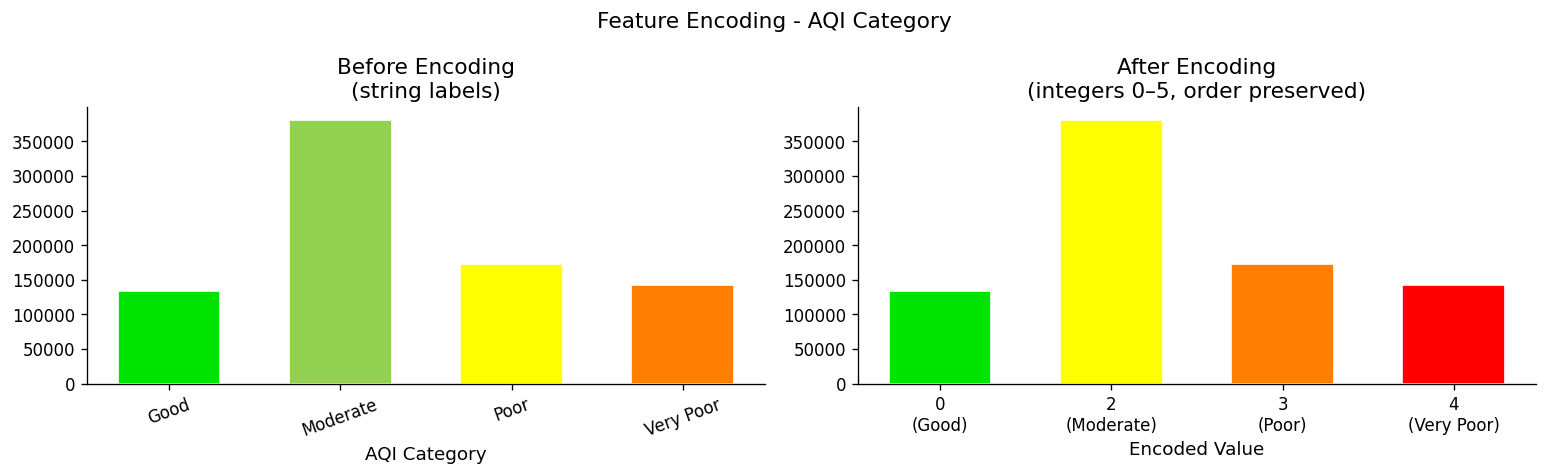


New columns added:
  aqi_category_enc  nulls: 0
  city_enc          nulls: 0


In [140]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ── AQI CATEGORY ENCODING (ORDINAL) ──────────────────────────────────────────
CAT_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
ordinal_map = {cat: i for i, cat in enumerate(CAT_ORDER)}

# map categories
df['aqi_category_enc'] = df[cat_col].map(ordinal_map)

# check unmapped values
unmapped = df['aqi_category_enc'].isnull().sum()

print('AQI category encoding:')
for cat, val in ordinal_map.items():
    count = (df[cat_col] == cat).sum()
    print(f'  {cat:<18} -> {val}   ({count:,} rows)')

print(f'\n  Unmapped rows : {unmapped:,}')

# 🔥 handle unmapped safely (important for ML)
df = df.dropna(subset=['aqi_category_enc'])

# convert to integer (VERY IMPORTANT)
df['aqi_category_enc'] = df['aqi_category_enc'].astype(int)


# ── CITY ENCODING (NOMINAL) ──────────────────────────────────────────────────
le_city = LabelEncoder()
df['city_enc'] = le_city.fit_transform(df[city_col].astype(str))

print(f'\nCity encoding:')
for i, city in enumerate(le_city.classes_):
    print(f'  {i:>2}  ->  {city}')


# ── BEFORE / AFTER PLOT ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# before encoding
cat_counts = df[cat_col].value_counts().reindex(CAT_ORDER).dropna()
cat_colors = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']

axes[0].bar(
    cat_counts.index,
    cat_counts.values,
    color=cat_colors[:len(cat_counts)],
    edgecolor='white',
    width=0.6
)
axes[0].set_title('Before Encoding\n(string labels)')
axes[0].set_xlabel('AQI Category')
axes[0].tick_params(axis='x', rotation=20)

# after encoding
enc_counts = df['aqi_category_enc'].value_counts().sort_index()

axes[1].bar(
    [f'{i}\n({CAT_ORDER[i]})' for i in enc_counts.index],
    enc_counts.values,
    color=[cat_colors[i] for i in enc_counts.index],
    edgecolor='white',
    width=0.6
)
axes[1].set_title('After Encoding\n(integers 0–5, order preserved)')
axes[1].set_xlabel('Encoded Value')

plt.suptitle('Feature Encoding - AQI Category', fontsize=13)
plt.tight_layout()
plt.show()


# ── FINAL CHECK ───────────────────────────────────────────────────────────────
print(f'\nNew columns added:')
print(f'  aqi_category_enc  nulls: {df["aqi_category_enc"].isnull().sum()}')
print(f'  city_enc          nulls: {df["city_enc"].isnull().sum()}')

<!-- section_5_feature_selection.md -->

## Section 5 - Feature Selection

Now we figure out which columns actually matter for prediction. Two approaches:

**Correlation matrix** — if two features are highly correlated with each other (PM2.5 and PM10 at r=0.83 for example), they carry almost the same information. Keeping both in a linear regression causes multicollinearity. We drop the weaker one.

**Random Forest importance** — we train a quick Random Forest on a sample and look at which features it uses most for splitting. Features with near-zero importance are noise and get dropped.

Whatever survives both checks becomes the final feature set used for both regression and classification.

Features going into selection : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'o3_ugm3', 'city_enc']
Rows available                : 829,617

Dropped due to high correlation (>0.85): []

Random Forest importance:
  pm2_5_ugm3             0.3359  ████████████████
  pm10_ugm3              0.2129  ██████████
  co_ugm3                0.1362  ██████
  o3_ugm3                0.1321  ██████
  no2_ugm3               0.1121  █████
  city_enc               0.0708  ███

Dropped due to low RF importance (<0.02): []

FINAL SELECTED FEATURES (6): ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'o3_ugm3', 'no2_ugm3', 'city_enc']


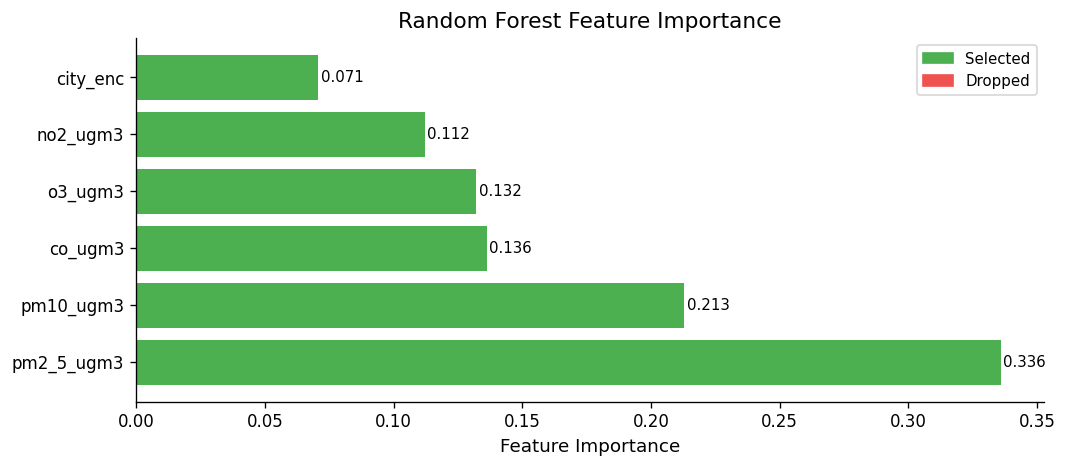

In [141]:
from sklearn.ensemble import RandomForestClassifier

# ── candidate features ────────────────────────────────────────────────────────
CANDIDATE_FEATURES = pollutant_cols + ['month', 'hour', 'day_of_week', 'city_enc']

available = [
    f for f in CANDIDATE_FEATURES
    if f in df.columns and df[f].isnull().sum() == 0
]

TARGET   = 'aqi_category_enc'
df_fs    = df[available + [TARGET]].dropna().copy()

print(f'Features going into selection : {available}')
print(f'Rows available                : {len(df_fs):,}')

# ── correlation check ─────────────────────────────────────────────────────────
corr_matrix  = df_fs[available].corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr    = [c for c in upper.columns if any(upper[c] > 0.85)]

print(f'\nDropped due to high correlation (>0.85): {drop_corr}')

after_corr = [f for f in available if f not in drop_corr]

# ── random forest importance ──────────────────────────────────────────────────
# sample 50k rows so this runs fast
sample      = df_fs.sample(n=min(50000, len(df_fs)), random_state=42)
rf          = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(sample[after_corr], sample[TARGET])

importance  = pd.Series(rf.feature_importances_, index=after_corr).sort_values(ascending=False)
drop_rf     = importance[importance < 0.02].index.tolist()
FINAL_FEATURES = importance[importance >= 0.02].index.tolist()

print(f'\nRandom Forest importance:')
for feat, val in importance.items():
    flag = '  <- dropped' if val < 0.02 else ''
    bar  = '█' * int(val * 50)
    print(f'  {feat:<22} {val:.4f}  {bar}{flag}')

print(f'\nDropped due to low RF importance (<0.02): {drop_rf}')
print(f'\nFINAL SELECTED FEATURES ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')

# ── importance bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors  = ['#4CAF50' if f in FINAL_FEATURES else '#EF5350' for f in importance.index]
bars    = ax.barh(importance.index, importance.values, color=colors)
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
green_p = mpatches.Patch(color='#4CAF50', label='Selected')
red_p   = mpatches.Patch(color='#EF5350', label='Dropped')
ax.legend(handles=[green_p, red_p], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()